# ==========================================
# OASIS INFOBYTE - DATA SCIENCE INTERNSHIP
# TASK 1: IRIS FLOWER CLASSIFICATION
# Author: Muhammad Farhan
# Track: Data Science
# Repo Name: OIBSIP
# ==========================================

### ==============================================================================
### SECTION 1: DATA LOADING, STRUCTURE INSPECTION & QUALITY CHECKS
### ==============================================================================
### Objective: Load the raw Iris dataset, convert it to a structured DataFrame,
### check for missing values, and analyze basic statistical metrics.
### Import required libraries

In [1]:
import warnings
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.datasets import load_iris

warnings.filterwarnings('ignore')

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

In [3]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [5]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In [6]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### ==============================================================================
### SECTION 2: VISUAL EXPLORATORY DATA ANALYSIS (EDA)
### ==============================================================================

In [7]:
df['species_name'] = df['species'].map(
    {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
)

<Figure size 720x576 with 0 Axes>

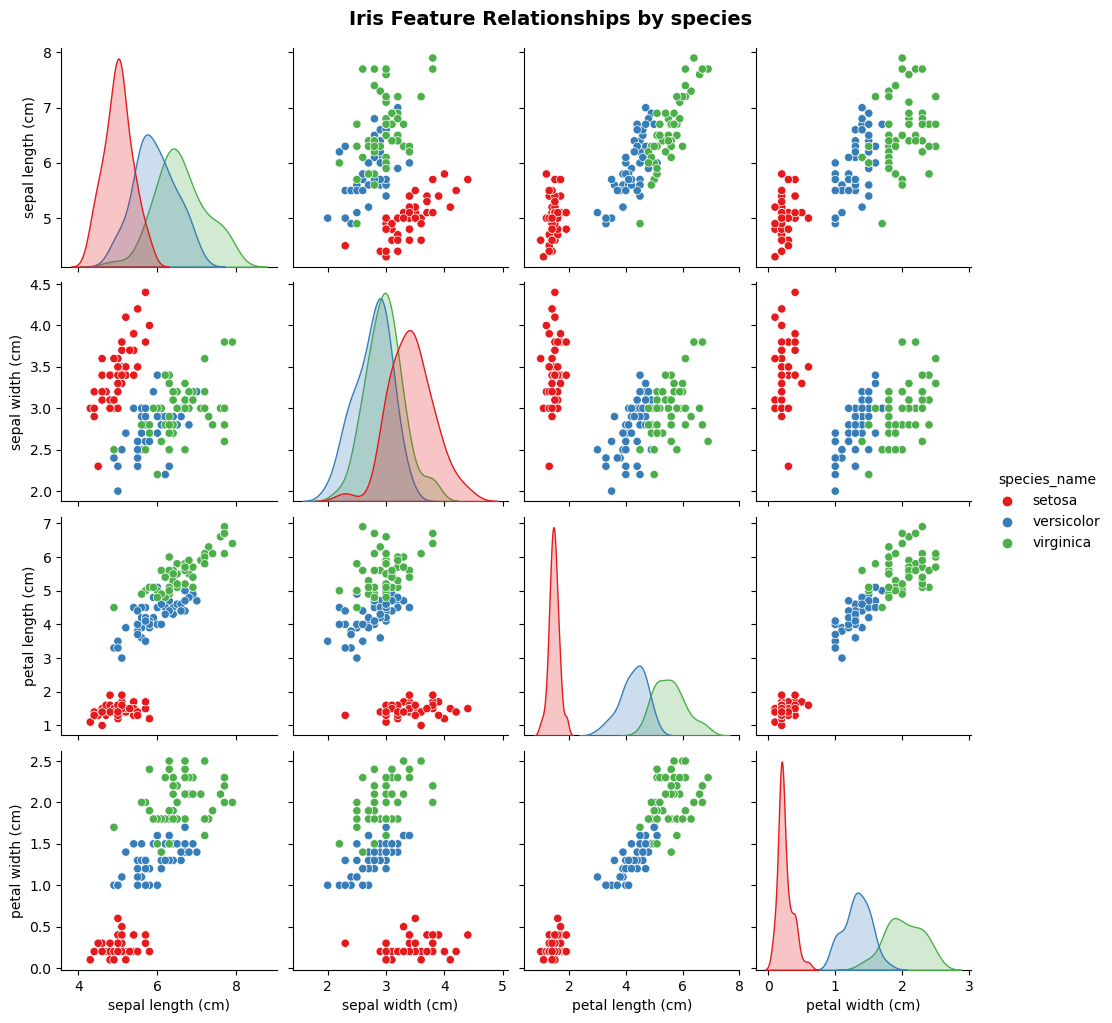

In [8]:
plt.figure(figsize=(10,8))
plt.style.use('seaborn-v0_8whitegrid' if 'seaborn-v0_8whitegrid' in plt.style.available else 'default')

sns.pairplot(df.drop('species' ,axis=1), hue='species_name', palette='Set1', diag_kind='kde')
plt.suptitle('Iris Feature Relationships by species', y=1.02 ,fontsize=14, fontweight='bold')

plt.savefig('iris _pairplot.png', bbox_inches='tight', dpi=300)
plt.show()

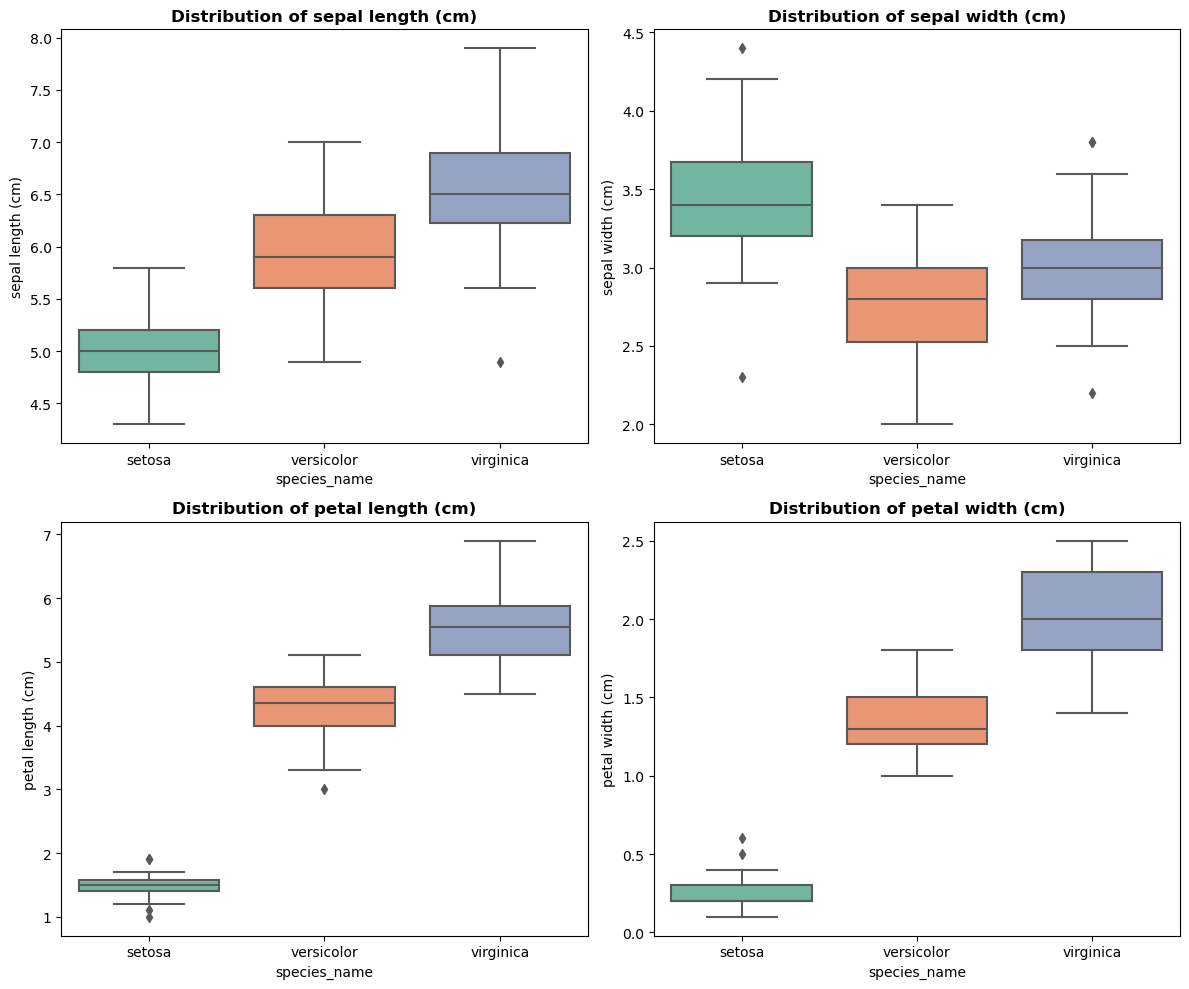

In [9]:
fig, axes  = plt.subplots(2, 2, figsize=(12,10))
features = iris.feature_names

for i, col in enumerate(features):
    row, c=i // 2, i % 2
    sns.boxplot(x='species_name', y=col , data=df, ax=axes [row, c], palette='Set2')
    axes[row, c].set_title(f"Distribution of {col}", fontweight='bold')

plt.tight_layout()

plt.savefig('iris_boxplots.png', bbox_inches='tight', dpi=300)
plt.show()

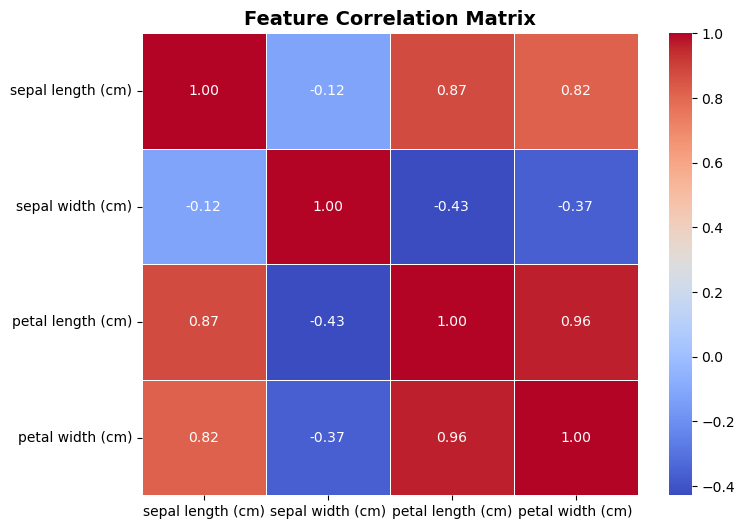

In [10]:
plt.figure(figsize=(8, 6))
feature_cols = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
corr_matrix = df[feature_cols].corr()


sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')


plt.savefig('iris_correlation_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()

### ==============================================================================
### Section 3: DATA PREPROCESSING & TRAIN-TEST SPLIT
### ==============================================================================

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X = df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
y = df['species']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y,  random_state=42, test_size=0.2, stratify=y)

In [14]:
print("=== TRAIN-TEST SPLIT SUMMARY ===")
print(f"Total Dataset Size : {len(df)} samples")
print(f"Training Set Size  : {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"Testing Set Size   : {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.0f}%)")

print("\n=== CLASS DISTRIBUTION IN TEST SET ===")
print(y_test.value_counts())

=== TRAIN-TEST SPLIT SUMMARY ===
Total Dataset Size : 150 samples
Training Set Size  : 120 samples (80%)
Testing Set Size   : 30 samples (20%)

=== CLASS DISTRIBUTION IN TEST SET ===
0    10
2    10
1    10
Name: species, dtype: int64


### ==============================================================================
### Section 4: MODEL TRAINING & EVALUATION (Logistic Regression)
### ==============================================================================

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [16]:
model = LogisticRegression(max_iter=200, random_state=42)

In [17]:
model.fit (X_train, y_train)

LogisticRegression(max_iter=200, random_state=42)

In [18]:
y_pred = model.predict(X_test)

In [19]:
accuracy = accuracy_score(y_test,y_pred)

In [20]:
print(f"=== MODEL ACCURACY: {accuracy * 100:.2f}% ===\n")
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['setosa', 'versicolor', 'virginica']))

=== MODEL ACCURACY: 96.67% ===

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### ==============================================================================
### Section 4 (CONTINUED): CONFUSION MATRIX VISUALIZATION
### ==============================================================================

In [21]:
cm = confusion_matrix(y_test, y_pred)

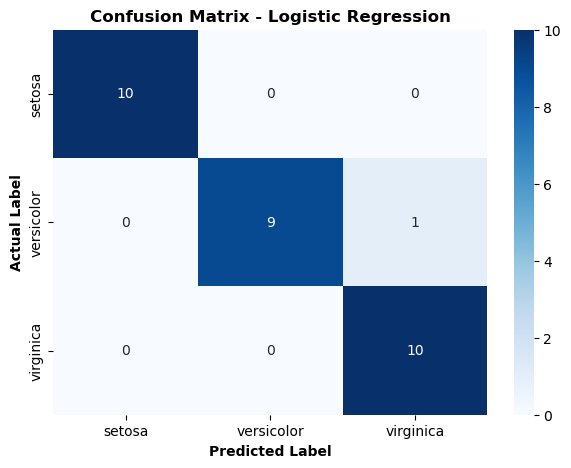

In [22]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['setosa', 'versicolor', 'virginica'],
            yticklabels=['setosa', 'versicolor', 'virginica'])

plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('Actual Label', fontweight='bold')
plt.title('Confusion Matrix - Logistic Regression', fontsize=12, fontweight='bold')
plt.savefig('iris_confusion_matrix.png', bbox_inches='tight', dpi=300)

plt.show()

### ==============================================================================
### Section 5: REAL-TIME SINGLE SAMPLE PREDICTION
### ==============================================================================

In [28]:
def predict_iris_species(sepal_length, sepal_width, petal_length, petal_width):
    sample_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    prediction_numeric = model.predict(sample_data)[0]
    species_map = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
    predicted_species = species_map[prediction_numeric]
    probabilities = model.predict_proba(sample_data)[0]

    print(f"=== PREDICTION RESULT ===")
    print(f"Predicted Class : {predicted_species}")
    print(f"Confidence      : {np.max(probabilities) * 100:.2f}%\n")
    print("Class Probabilities:")
    for species, prob in zip(species_map.values(), probabilities):
        print(f" - {species}: {prob*100:.2f}%")
        
predict_iris_species(4.00, 2.00, 1.4, 0.2)

=== PREDICTION RESULT ===
Predicted Class : Setosa
Confidence      : 96.37%

Class Probabilities:
 - Setosa: 96.37%
 - Versicolor: 3.63%
 - Virginica: 0.00%


In [24]:
df.to_csv('iris_dataset.csv', index=False)
print("Dataset successfully saved as iris_dataset.csv!")

Dataset successfully saved as iris_dataset.csv!


In [26]:
import joblib
joblib.dump(model,'iris_model.pkl')

['iris_model.pkl']